In [1]:
!pip install rasterio numpy

In [3]:
import rasterio 
import numpy as np
import os 
from rasterio.windows import Window

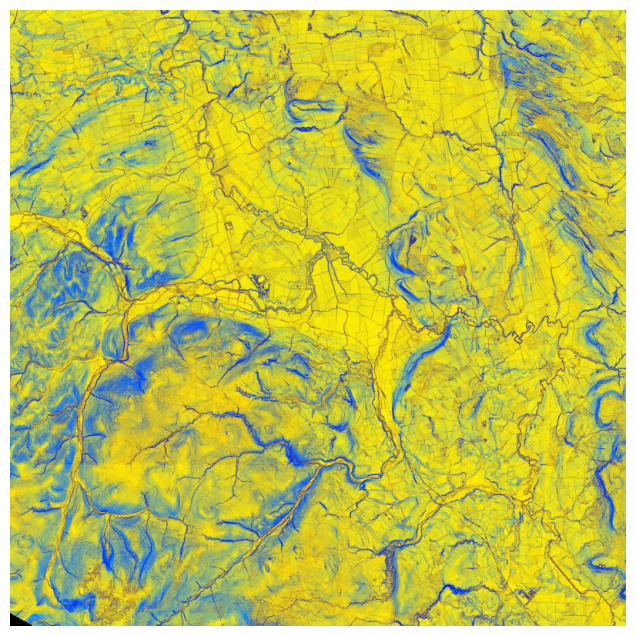

In [7]:
ne_merged_refined = "/Users/rajkamal0raon/Desktop/ne_merged_refined.tif"


from rasterio.enums import Resampling
import matplotlib.pyplot as plt

# read RGB composite at reduced resolution
with rasterio.open(ne_merged_refined) as ds:
    image = ds.read(out_shape = (3,800,800) , resampling = Resampling.average)
# display RGB composite
plt.figure(figsize = (8,8))
plt.imshow(image.transpose(1,2,0))  # rearrange from (3,H,W) to (H,W,3) for matplotlib
plt.axis("off")
plt.show()

In [8]:
def tile_data(input_path , tile_dir,tile_size = 640 , overlap = 128):
    # split data into tile size * tile size GeoTIFF tiles

    os.makedirs(tile_dir , exist_ok = True)
    step = tile_size-overlap
    tiles_written = 0
    with rasterio.open(input_path) as ds:
        width , height = ds.width, ds.height

        for top in range(0,height,step): # move down
            for left in range(0,width,step): # move right
                window_width = min(tile_size,width -left)
                window_height = min(tile_size,height-top)
                if window_width <=0 or window_height <=0:
                    continue
                window = Window(left,top,window_width,window_height)  # create the window
                
                transform = ds.window_transform(window)  # get geographic position
                tile_array = ds.read(window = window) # read the tile data 
                tile_profile = ds.profile.copy()
                tile_profile.update(
                    height = window_height,
                    width = window_width,
                    transform = transform,
                )

                # save each tile as a separate GeoTIFF
                tile_name = f"tile_{top}_{left}.tif"
                tile_path = os.path.join(tile_dir , tile_name)
                with rasterio.open(tile_path , "w",**tile_profile) as f:
                    f.write(tile_array)
                tiles_written +=1

    print(f"{tiles_written} tiles written :{tile_dir}")
    return tiles_written
                
             
                
                 
                

In [9]:
ne_merged_refined = "/Users/rajkamal0raon/Desktop/ne_merged_refined.tif"
Tile_dir_ne_refined = "/Users/rajkamal0raon/Desktop/dataset1/ne_refined_tile"
tile_data(ne_merged_refined,Tile_dir_ne_refined, tile_size = 640 , overlap = 0) # no overlap for test



1155 tiles written :/Users/rajkamal0raon/Desktop/dataset1/ne_refined_tile


1155

In [10]:
# Sanity check to verify the tiles were created correctly

files = os.listdir(Tile_dir_ne_refined)
print("Total files :", len(files))
print("sample names:",files[:5])

# check all files for zero size
zero_files = 0
for f in files:
    size = os.path.getsize(os.path.join(Tile_dir_ne_refined,f))
    if size == 0:
        zero_files +=1
        print(f"WARNING : {f} is empty")
if zero_files == 0:
    print("All tiles have data")
else:
    print(f"{zero_files} empty files found")


Total files : 1155
sample names: ['tile_6400_8960.tif', 'tile_9600_13440.tif', 'tile_5120_16640.tif', 'tile_5760_11520.tif', 'tile_16640_1920.tif']
All tiles have data


In [11]:
#conversion into JPG for detection 
from PIL import Image

tif_dir = Tile_dir_ne_refined
jpg_dir_ne_merged = "/Users/rajkamal0raon/Desktop/dataset1/ne_merged_refined_tile_jpg"
os.makedirs(jpg_dir_ne_merged , exist_ok = True)

converted = 0
for tile in os.listdir(tif_dir):
    if tile.endswith(".tif"):
        
        # read GeoTIFF
        with rasterio.open(os.path.join(tif_dir,tile))as ds:
            arr = ds.read()   # shape:(3,H,W)

        # convert to JPG
        img = np.transpose(arr,(1,2,0))  # rearrange to (H,W,3) for PIL
        out_name = tile.replace(".tif",".jpg")
        Image.fromarray(img, mode = "RGB").save(os.path.join(jpg_dir_ne_merged , out_name), quality = 95)
        converted +=1

print(f"{converted} tiles converted to JPG : {jpg_dir_ne_merged}")
            


1155 tiles converted to JPG : /Users/rajkamal0raon/Desktop/dataset1/ne_merged_refined_tile_jpg


In [12]:
print(os.path.abspath("ne_merged_refined_tile_jpg"))
print(os.path.abspath("ne_refined_tile"))

/Users/rajkamal0raon/ne_merged_refined_tile_jpg
/Users/rajkamal0raon/ne_refined_tile


In [14]:
with rasterio.open("/Users/rajkamal0raon/Desktop/ne_merged_refined.tif")as ds:
    print("Raster CRS :", ds.crs)
    print("Raster Bounds:",ds.bounds)


Raster CRS : EPSG:27700
Raster Bounds: BoundingBox(left=386462.0, bottom=619529.0, right=408365.0, top=640374.0)


In [15]:
import shutil
shutil.make_archive(
    "/Users/rajkamal0raon/Desktop/dataset1/ne_merged_refined_tile_jpg",
    "zip",
   "/Users/rajkamal0raon/Desktop/dataset1/ne_merged_refined_tile_jpg"
)
print("Zipped!")

Zipped!
